Import necessary libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read datasets

In [33]:
responses = pd.read_csv("../../data/raw/counterfactual_responses_raw.csv")
metadata = pd.read_csv("../../data/raw/metadata_raw.csv")

Response data cleaning steps

In [34]:
responses = responses.rename(
    columns={"Partcipant_ID": "Participant_ID"}
)

responses["Response"] = (
    responses["Response"]
    .str.strip()
)

responses.shape

(336, 9)

Metadata cleaning steps

In [35]:
metadata.columns = metadata.columns.str.strip()

metadata = metadata.drop(columns = ["Agent"])

metadata.shape

(56, 18)

Add professional need and professional use labels in metadata

In [36]:
prof_mapping = {
    0: "No",
    1: "Yes"
}

metadata["Prof_Need_Label"] = (
    metadata["Prof_Need"]
    .map(prof_mapping)
)

metadata["Prof_Use_Label"] = (
    metadata["Prof_Use"]
    .map(prof_mapping)
)

Merge datasets and check null values

In [37]:
merged_data = responses.merge(
    metadata,
    on= "Participant_ID",
    how="left"
)

In [38]:
merged_data.head()

,Participant_ID,Focus,Agent,Goal_Type,Item,Item_string,Item_len,Response_tag,Response,EXP,...,Multi_Spk,Immersion,Prof_Need,Prof_Use,Motivation,Distractor,GN_Score,Difficulty,Prof_Need_Label,Prof_Use_Label
0,EXP1_01,I,1,no_goal,Item1,"""If I had heard the rainstorm, I would have fe...",11,L1_transfer_3,L1_transfer,1,...,1,0,1,1,4,4,23,3,Yes,Yes
1,EXP1_01,I,1,no_goal,Item2,"""If I had climbed the mountain cliff, I would ...",12,L1_transfer_3,L1_transfer,1,...,1,0,1,1,4,4,23,3,Yes,Yes
2,EXP1_01,I,1,goal_non_frequent,Item1,"""If I had created an online platform, I would ...",14,L1_transfer_3,L1_transfer,1,...,1,0,1,1,4,4,23,3,Yes,Yes
3,EXP1_01,I,1,goal_non_frequent,Item2,"""If I had invested in technology, I would have...",13,correct_3,correct,1,...,1,0,1,1,4,4,23,3,Yes,Yes
4,EXP1_01,I,1,goal_frequent,Item1,"""If I had saved money, I would have gone on ho...",11,correct_3,correct,1,...,1,0,1,1,4,4,23,3,Yes,Yes


In [39]:
merged_data.shape

(336, 28)

In [40]:
merged_data.columns

Index(['Participant_ID', 'Focus', 'Agent', 'Goal_Type', 'Item', 'Item_string',
       'Item_len', 'Response_tag', 'Response', 'EXP', 'n', 'Age', 'Gender',
       'Kno_Level', 'Per_Level', 'Bilingual', 'Bi_Parents', 'Multi_Kno',
       'Multi_Spk', 'Immersion', 'Prof_Need', 'Prof_Use', 'Motivation',
       'Distractor', 'GN_Score', 'Difficulty', 'Prof_Need_Label',
       'Prof_Use_Label'],
      dtype='str')

In [41]:
merged_data[["Prof_Need", "Prof_Need_Label", "Prof_Use", "Prof_Use_Label"]].head(10)

,Prof_Need,Prof_Need_Label,Prof_Use,Prof_Use_Label
0,1,Yes,1,Yes
1,1,Yes,1,Yes
2,1,Yes,1,Yes
3,1,Yes,1,Yes
4,1,Yes,1,Yes
5,1,Yes,1,Yes
6,0,No,0,No
7,0,No,0,No
8,0,No,0,No
9,0,No,0,No


Convert nulls into explicit label temporarily

In [42]:
merged_data["Response_Full"] = (
    merged_data["Response"]
    .fillna("null")
)

Counts and Proportions of Responses by Professional Need

In [43]:
pd.crosstab(
    merged_data["Prof_Need_Label"],
    merged_data["Response_Full"]
)

Response_Full,L1_transfer,L2_other,correct,null
Prof_Need_Label,,,,
No,16,9,21,2
Yes,133,63,83,9


In [44]:
prof_need_response_props = pd.crosstab(
    merged_data["Prof_Need_Label"],
    merged_data["Response_Full"],
    normalize= "index"
)

prof_need_response_props

Response_Full,L1_transfer,L2_other,correct,null
Prof_Need_Label,,,,
No,0.333333,0.18750,0.437500,0.041667
Yes,0.461806,0.21875,0.288194,0.031250


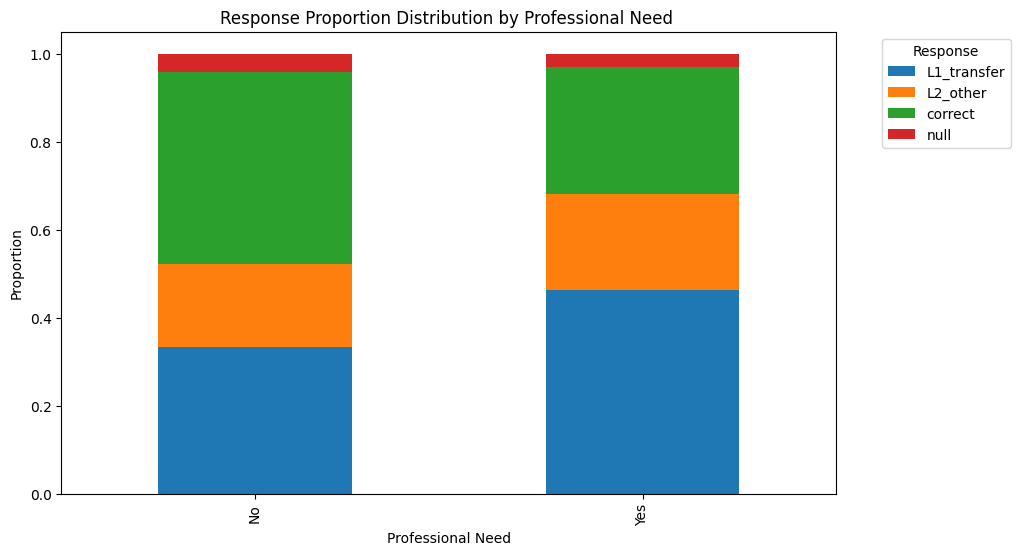

In [45]:
prof_need_response_props.plot(kind="bar", stacked=True, figsize= (10,6))

plt.title("Response Proportion Distribution by Professional Need ")
plt.xlabel("Professional Need")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()

Counts and Proportions of Responses by Professional Use

In [46]:
pd.crosstab(
    merged_data["Prof_Use_Label"],
    merged_data["Response_Full"]
)

Response_Full,L1_transfer,L2_other,correct,null
Prof_Use_Label,,,,
No,49,31,34,6
Yes,100,41,70,5


In [47]:
prof_use_response_props = pd.crosstab(
    merged_data["Prof_Use_Label"],
    merged_data["Response_Full"],
    normalize= "index"
)

prof_use_response_props

Response_Full,L1_transfer,L2_other,correct,null
Prof_Use_Label,,,,
No,0.408333,0.258333,0.283333,0.050000
Yes,0.462963,0.189815,0.324074,0.023148


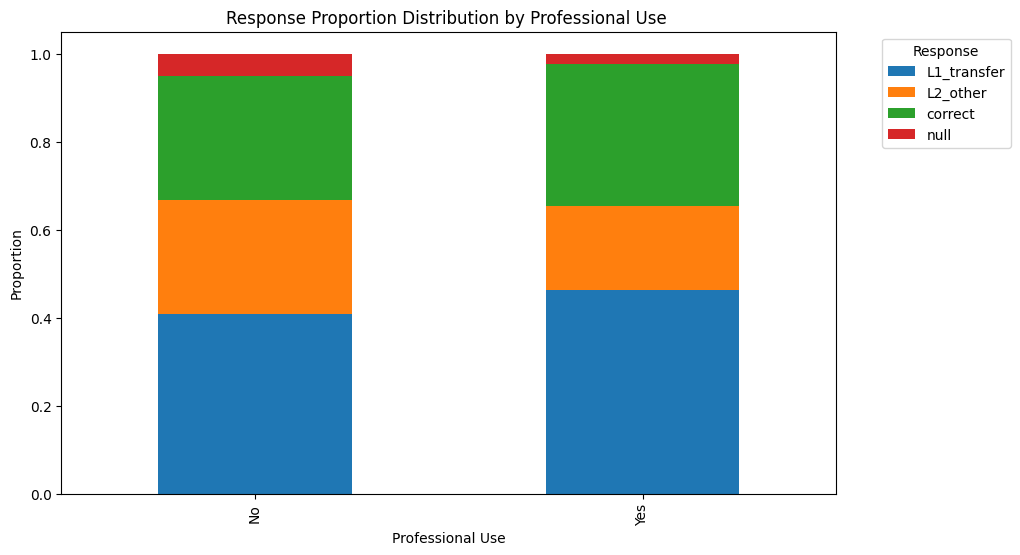

In [48]:
prof_use_response_props.plot(kind="bar", stacked=True, figsize= (10,6))

plt.title("Response Proportion Distribution by Professional Use ")
plt.xlabel("Professional Use")
plt.ylabel("Proportion")
plt.legend(title = "Response", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()

Inspect potential subgroup distribution: proficiency (perceived level) and exposure (professional use)

Include Per_Level_Labels from B1.2 to C1 in the subset

In [50]:
level_mapping = {
    1: "A1",
    2: "A2.1",
    3: "A2.2",
    4: "B1.1",
    5: "B1.2",
    6: "B2.1",
    7: "B2.2",
    8: "C1",
    9: "C2"
}

merged_data["Per_Level_Label"] = (
    merged_data["Per_Level"]
    .map(level_mapping)
)

level_order = [
    "A1",
    "A2.1",
    "A2.2",
    "B1.1",
    "B1.2",
    "B2.1",
    "B2.2",
    "C1",
    "C2"
]

merged_data["Per_Level_Label"] = pd.Categorical(
    merged_data["Per_Level_Label"],
    categories=level_order,
    ordered=True
)


subset = merged_data[
    merged_data["Per_Level_Label"].isin(
        ["B1.2", "B2.1", "B2.2", "C1"]
    )
]


In [51]:
subset.shape

(330, 30)

In [52]:
pd.crosstab(
    subset["Per_Level_Label"],
    subset["Prof_Use_Label"]
)

Prof_Use_Label,No,Yes
Per_Level_Label,,
B1.2,30,12
B2.1,12,54
B2.2,72,90
C1,6,54


In [53]:
subset_props =pd.crosstab(
    subset["Per_Level_Label"],
    subset["Prof_Use_Label"],
    normalize="index"
)

subset_props

Prof_Use_Label,No,Yes
Per_Level_Label,,
B1.2,0.714286,0.285714
B2.1,0.181818,0.818182
B2.2,0.444444,0.555556
C1,0.100000,0.900000


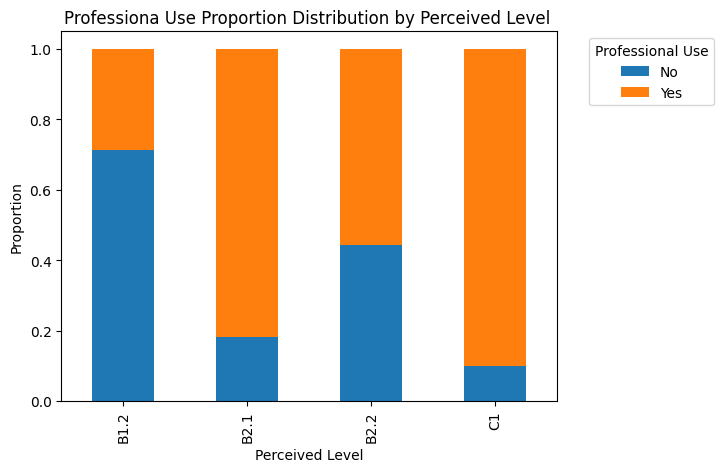

In [55]:
subset_props.plot(kind = "bar", stacked = True)
plt.title("Professiona Use Proportion Distribution by Perceived Level ")
plt.xlabel("Perceived Level")
plt.ylabel("Proportion")
plt.legend(title = "Professional Use", bbox_to_anchor= (1.05, 1), loc= "upper left")

plt.show()